*IMPORTAR LIRERIAS*

torch = PyTorch modelo
numpy = base matemática
datasets → cargar imágenes
transforms → preparar datosdatasets → cargar imágenes

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from collections import OrderedDict
from torchvision import datasets, transforms

*CARGAR MNIST*
Según la guía:

Se usa DataLoader para manejar los datos en batches.

Para no cargar 10,000 imágenes de una y mejr se carga en grupos de 64, entonces lo que haremos es: 
- Preparación de los datos
Se transforman las imágenes en tensores y se escalan sus valores para que estén en un rango entre -1 y 1.
- Carga del conjunto de datos MNIST
Se utiliza el dataset MNIST, que contiene imágenes de números escritos a mano, para trabajar y entrenar el modelo.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#Dataset MINIST
trainset = datasets.MNIST('MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = datasets.MNIST('MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

100.0%
100.0%
100.0%
100.0%


*VER DATOS*

Aqui vamos a obtener un lote de datos para probar la red
dataiter = iter(trainloader)

Donde:
64 - batch
1 - canal (balnco/negro)
28x28 - tamaño de imagen  



In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print("Shape de imágenes:",images.shape)

Shape de imágenes: torch.Size([64, 1, 28, 28])


*CONSTRUIR LA RED NEURONAL*
Se implementó una red neuronal completamente conectada (feedforward) utilizando la clase Sequential de PyTorch. La arquitectura consta de tres capas ocultas con 400, 200 y 100 neuronas respectivamente. Cada capa utiliza la función de activación ReLU para introducir no linealidad en el modelo.

-Capa 1: entrada -> 400
-Capa 2: 400 -> 200
-Capa 3: 200 -> 100
Salida: 100 -> 10

In [ ]:
input_size = 784                  # 28x28 píxeles = 784 entradas
hidden_sizes = [400, 200, 100]    # Tres capas ocultas con distintas unidades
output_size = 10 

model = nn.Sequential(OrderedDict([
    ('fc1', nn.Linear(input_size, hidden_sizes[0])),
    ('relu1', nn.ReLU()),
    ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
    ('relu2', nn.ReLU()),
    ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
    ('relu3', nn.ReLU()),
    ('output', nn.Linear(hidden_sizes[2], output_size)),
    ('softmax', nn.Softmax(dim=1))
]))

print(model)

Sequential(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=400, out_features=200, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=200, out_features=100, bias=True)
  (relu3): ReLU()
  (output): Linear(in_features=100, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


Se realizó un forward pass utilizando una imagen del dataset, donde los datos de entrada son propagados a través de la red neuronal. Debido a que el modelo no ha sido entrenado, las probabilidades obtenidas son aleatorias.

Probabilidades: tensor([[0.1064, 0.1028, 0.0944, 0.0882, 0.1050, 0.1006, 0.0943, 0.1001, 0.0979,
         0.1102]], grad_fn=<SoftmaxBackward0>)


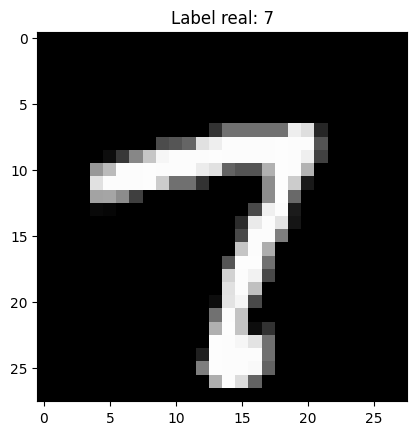

In [ ]:
# PREPARAR DATOS (IMPORTANTE)
images = images.view(images.shape[0], -1)

# FORWARD PASS
ps = model(images[0].unsqueeze(0))

print("Probabilidades:", ps)

# MOSTRAR IMAGEN
plt.imshow(images[0].view(28, 28), cmap='gray')
plt.title(f"Label real: {labels[0].item()}")
plt.show()